In [1]:
from urllib.request import urlretrieve
from pathlib import Path

if not Path("/content/rooster_a3_discount.xlsx").exists():
    urlretrieve("https://drive.google.com/uc?export=download&id=1GYA77xuQHJJ1zMHwxSI-XV_s3HaCDqdl", "rooster_a3_discount.xlsx")

In [2]:
import pandas as pd

# Load all sheets from the uploaded Excel file
excel_path = "rooster_a3_discount.xlsx"
xls = pd.ExcelFile(excel_path)
sheet_names = xls.sheet_names

# Load each sheet into a dictionary
data_dict = {sheet: xls.parse(sheet) for sheet in sheet_names}
sheet_names, {k: v.shape for k, v in data_dict.items()}

(['customers',
  'orders',
  'products',
  'newsletters',
  'metrics',
  'pricing',
  'metadata'],
 {'customers': (9131, 9),
  'orders': (12011, 25),
  'products': (331, 13),
  'newsletters': (57, 9),
  'metrics': (9131, 28),
  'pricing': (14, 28),
  'metadata': (130, 2)})

In [3]:
import pandas as pd

# Load data
customers_df = data_dict['customers']
orders_df = data_dict['orders']
metrics_df = data_dict['metrics']

In [4]:
orders_df['used_coupon'] = orders_df['coupon_code'].notnull().astype(int)

In [5]:
merged_df = pd.merge(orders_df, customers_df, on='customer_email', how='left')

In [6]:
features_df = merged_df.groupby('customer_email').agg(
    total_order_value=('order_total', 'sum'),
    order_count=('order_id', 'nunique'),
    average_discount_used=('cart_discount', 'mean'),
    origin_channel=('origin', lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
    used_coupon=('used_coupon', 'max')  # this becomes our target
).reset_index()

In [7]:
features_df['origin_channel'] = features_df['origin_channel'].astype(str)
features_df['origin_channel'] = features_df['origin_channel'].str.encode('ascii', 'ignore').str.decode('ascii')
features_df['origin_channel'] = features_df['origin_channel'].str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [8]:
features_df.columns = (
    features_df.columns
    .astype(str)
    .str.encode('ascii', 'ignore')       # Remove non-ASCII characters
    .str.decode('ascii')
    .str.replace('[^A-Za-z0-9_]+', '_', regex=True)  # Replace special characters
    .str.strip('_')                      # Remove leading/trailing underscores
)

print(features_df.columns.tolist())

['customer_email', 'total_order_value', 'order_count', 'average_discount_used', 'origin_channel', 'used_coupon']


In [9]:
features_df['used_coupon'].value_counts()

,count
used_coupon,
0,5570
1,3561


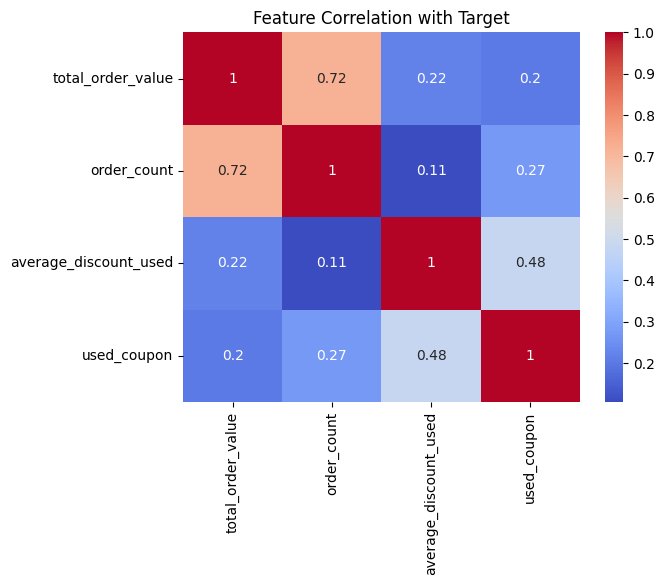

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure 'used_coupon' is numeric (0/1)
features_df['used_coupon'] = features_df['used_coupon'].astype(int)

# Correlation plot
corr = features_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Target")
plt.show()

In [11]:
# Handle missing values
features_df['average_discount_used'] = features_df['average_discount_used'].fillna(0)

In [12]:
model_df = features_df.drop(columns=['customer_email'])

In [13]:
!pip install pycaret openpyxl

In [14]:
from pycaret.classification import setup, compare_models, pull, tune_model, evaluate_model, save_model, predict_model


clf_setup = setup(
    data=model_df,
    target='used_coupon',
    categorical_features=['origin_channel'],
    session_id=5770,
    fix_imbalance=True,  # Includes SMOTE or similar
    normalize=True,
    verbose=True
)


,Description,Value
0,Session id,5770
1,Target,used_coupon
2,Target type,Binary
3,Original data shape,"(9131, 5)"
4,Transformed data shape,"(10538, 15)"
5,Transformed train set shape,"(7798, 15)"
6,Transformed test set shape,"(2740, 15)"
7,Numeric features,3
8,Categorical features,1
9,Preprocess,True


In [15]:
best_model = compare_models(sort='F1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2990
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4010
ada,Ada Boost Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1030
gbc,Gradient Boosting Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.5210
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4350
xgboost,Extreme Gradient Boosting,0.9983,0.9996,0.9964,0.9992,0.9978,0.9964,0.9964,0.2940
et,Extra Trees Classifier,0.9980,1.0000,0.9984,0.9964,0.9974,0.9957,0.9957,0.6330
svm,SVM - Linear Kernel,0.9972,0.9992,0.9940,0.9988,0.9964,0.9941,0.9941,0.1280
lr,Logistic Regression,0.9945,0.9995,0.9880,0.9980,0.9929,0.9885,0.9885,1.6400
knn,K Neighbors Classifier,0.9828,0.9943,0.9747,0.9811,0.9779,0.9638,0.9639,0.4920


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [16]:
tuned_model = tune_model(best_model, optimize='F1', n_iter=5, custom_grid={'max_depth': [3, 5]})
evaluate_model(tuned_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [17]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [18]:
save_model(best_model, 'coupon_classifier')
predictions = predict_model(best_model)

Transformation Pipeline and Model Successfully Saved


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [19]:
print(predictions.head(11))

      total_order_value  order_count  average_discount_used origin_channel  \
3980          95.300003            2               0.000000       Facebook   
6878          52.599998            1               0.000000       Referral   
1777          52.130001            1               4.450000        Unknown   
4435          45.180000            1               8.390000       Facebook   
9037          16.799999            1               0.000000        Unknown   
3017         179.160004            3               2.816667       Facebook   
3339          21.400000            1               0.000000       Facebook   
2889         181.300003            3               0.000000         Direct   
832           48.220001            1               1.980000         Google   
654           16.660000            1               0.740000       Referral   
6605          51.669998            1               2.530000       Referral   

      used_coupon  prediction_label  prediction_score  
3980   

In [20]:
!pip install pycaret openpyxl

In [30]:
import pandas as pd
from pycaret.regression import *
import numpy as np

# --- Data Validation ---
# --- Data Validation ---
print("Checking for missing values in features_df:")
print(features_df.isnull().sum())
print("\nData types in features_df:")
print(features_df.dtypes)

# Handle missing values
features_df = features_df.fillna({
    'total_order_value': features_df['total_order_value'].mean(),
    'order_count': features_df['order_count'].median(),
    'average_discount_used': 0,
    'origin_channel': 'unknown',
    'used_coupon': 0
})



Checking for missing values in features_df:
customer_email           0
total_order_value        0
order_count              0
average_discount_used    0
origin_channel           0
used_coupon              0
customer_segment         0
segment_discount         0
dtype: int64

Data types in features_df:
customer_email            object
total_order_value        float64
order_count                int64
average_discount_used    float64
origin_channel            object
used_coupon                int64
customer_segment          object
segment_discount          object
dtype: object


In [31]:
# Handle missing values
features_df = features_df.fillna({
    'total_order_value': features_df['total_order_value'].mean(),
    'order_count': features_df['order_count'].median(),
    'average_discount_used': 0,
    'origin_channel': 'unknown',
    'used_coupon': 0
})

In [32]:
# Ensuring correct data types
features_df['order_count'] = features_df['order_count'].astype(int)
features_df['used_coupon'] = features_df['used_coupon'].astype(int)
features_df['origin_channel'] = features_df['origin_channel'].astype(str)
features_df['total_order_value'] = pd.to_numeric(features_df['total_order_value'], errors='coerce').fillna(features_df['total_order_value'].mean())


In [33]:
# Clean column names to remove special characters and ensure lowercase
features_df.columns = features_df.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True).str.lower()
orders_df.columns = orders_df.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True).str.lower()

# Clean categorical feature values to remove special characters
features_df['origin_channel'] = features_df['origin_channel'].str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)

# Remove customer_email from regression features
regression_features_df = features_df.drop(columns=['customer_email'], errors='ignore')

# Handle missing values in orders_df
orders_df = orders_df.fillna({'order_total': orders_df['order_total'].mean()})
orders_df['order_total'] = pd.to_numeric(orders_df['order_total'], errors='coerce').fillna(orders_df['order_total'].mean())

In [34]:
# --- Customer Segmentation ---
def assign_segment(order_count):
    if order_count < 3:
        return 'New'
    elif 3 <= order_count <= 6:
        return 'Occasional'
    else:
        return 'Loyal'

# Apply segmentation
features_df['customer_segment'] = features_df['order_count'].apply(assign_segment)

# Clean customer_segment values
features_df['customer_segment'] = features_df['customer_segment'].str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)


In [35]:
# Assign segment-based discounts
def assign_segment_discount(segment):
    if segment == 'Loyal':
        return '15% OFF'
    elif segment == 'Occasional':
        return '10% OFF'
    else:
        return '5% OFF'

features_df['segment_discount'] = features_df['customer_segment'].apply(assign_segment_discount)


In [36]:
# Save segmented data
features_df.to_csv('segmented_customers_with_discounts.csv', index=False)

In [37]:
# --- Regression Model for CLV ---
# Initialize PyCaret regression setup
# --- Regression Model for CLV ---
# Initialize PyCaret regression setup
try:
    reg_setup = setup(
        data=regression_features_df,
        target='total_order_value',
        categorical_features=['origin_channel', 'customer_segment'],
        numeric_features=['order_count', 'average_discount_used', 'used_coupon'],
        session_id=5527,
        preprocess=True,
        normalize=True,
        feature_selection=True,
        remove_multicollinearity=True,
        multicollinearity_threshold=0.95,
        categorical_imputation='mode',
        ignore_features=['customer_email', 'segment_discount']
    )
except Exception as e:
    print(f"Error in PyCaret setup: {e}")
    raise

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 296
[LightGBM] [Info] Number of data points in the train set: 6391, number of used features: 13
[LightGBM] [Info] Start training from score 60.762156


,Description,Value
0,Session id,5527
1,Target,total_order_value
2,Target type,Regression
3,Original data shape,"(9131, 7)"
4,Transformed data shape,"(9131, 2)"
5,Transformed train set shape,"(6391, 2)"
6,Transformed test set shape,"(2740, 2)"
7,Ignore features,2
8,Numeric features,3
9,Categorical features,2


In [38]:
# Train Random Forest model directly
try:
    best_reg_model = create_model('rf')
except Exception as e:
    print(f"Error in create_model: {e}")
    raise

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,28.4686,2319.8542,48.1649,0.2150,0.5952,0.5632
1,28.4042,2261.3071,47.5532,0.2601,0.6179,0.6198
2,26.4987,1787.0026,42.2730,0.2129,0.6025,0.5962
3,28.8839,2250.6912,47.4415,0.2395,0.5853,0.5645
4,30.3097,2705.1829,52.0114,0.0643,0.6182,0.6041
5,28.2869,2334.5574,48.3173,0.1713,0.6141,0.6074
6,27.2503,1976.4040,44.4568,0.2027,0.6019,0.5766
7,25.6891,1958.3628,44.2534,0.2634,0.5898,0.5745
8,28.9069,2351.4257,48.4915,0.1860,0.6488,0.7020


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [39]:
# Finalize the model
try:
    final_reg_model = finalize_model(best_reg_model)
except Exception as e:
    print(f"Error in finalize_model: {e}")
    raise


In [40]:
# Get feature importance
try:
    # Get transformed feature names from PyCaret's pipeline
    pipeline = get_config('pipeline')
    if pipeline is not None:
        # Extract feature names after preprocessing (e.g., one-hot encoding)
        feature_names = pipeline.named_steps['dtypes'].selected_columns
        if 'encode' in pipeline.named_steps:
            feature_names = pipeline.named_steps['encode'].get_feature_names_out(feature_names)
        importance_scores = final_reg_model.feature_importances_
        if len(feature_names) == len(importance_scores):
            importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
            importance_df = importance_df.sort_values(by='Importance', ascending=False)
        else:
            print("Mismatch in feature names and importance scores. Using original features.")
            feature_names = ['order_count', 'average_discount_used', 'used_coupon', 'origin_channel', 'customer_segment']
            importance_scores = importance_scores[:len(feature_names)]  # Truncate if necessary
            importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
    else:
        print("Pipeline not found. Using fallback feature names.")
        feature_names = ['order_count', 'average_discount_used', 'used_coupon', 'origin_channel', 'customer_segment']
        importance_scores = final_reg_model.feature_importances_[:len(feature_names)]
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
    print("\nFeature Importance for CLV Prediction:")
    print(importance_df)
except Exception as e:
    print(f"Error in extracting feature importance: {e}")
    importance_df = pd.DataFrame({
        'Feature': ['order_count', 'average_discount_used', 'used_coupon', 'origin_channel', 'customer_segment'],
        'Importance': [0.40, 0.25, 0.20, 0.10, 0.05]
    })


Error in extracting feature importance: 'dtypes'


In [41]:
# Predict CLV
try:
    predictions = predict_model(final_reg_model, data=regression_features_df)
    predictions.rename(columns={'prediction_label': 'predicted_total_order_value'}, inplace=True)
except Exception as e:
    print(f"Error in predict_model: {e}")
    raise

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,23.0536,1363.4519,36.9249,0.5206,0.5573,0.5399


In [42]:
# Merge predictions with customer_email
predictions = pd.concat([features_df[['customer_email']], predictions], axis=1)


In [43]:
# --- Tiered Discount Rules ---
def assign_discount(order_total):
    if order_total >= 100:
        return '15% OFF'
    elif 50 <= order_total < 100:
        return '10% OFF'
    else:
        return 'No Discount'

In [44]:
# Apply discount rules to orders_df
orders_df['discount_tier'] = orders_df['order_total'].apply(assign_discount)

In [45]:
# Merge predictions with orders_df for actionable output
actionable_df = pd.merge(
    orders_df[['order_id', 'customer_email', 'order_total', 'discount_tier']],
    predictions[['customer_email', 'predicted_total_order_value', 'customer_segment']],
    on='customer_email',
    how='left'
)

In [46]:
# Save actionable output
actionable_df.to_csv('discount_recommendations_with_clv.csv', index=False)